In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [ ]:
#  importing the  data sets  from the kersas library minist data set
mnist = keras.datasets.mnist

# loading the data set into the train and test data sets
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()


In [ ]:
x_train_full.shape


(60000, 28, 28)

In [ ]:
x_train_full


array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
x_test.shape


(10000, 28, 28)

In [ ]:
x_test[0]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

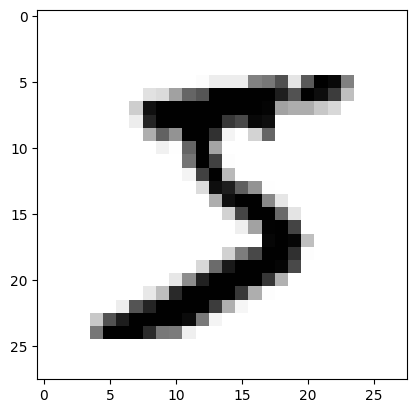

In [ ]:
#  Draw the first image in the training data set
plt.imshow(x_train_full[0], cmap="binary")
plt.show()


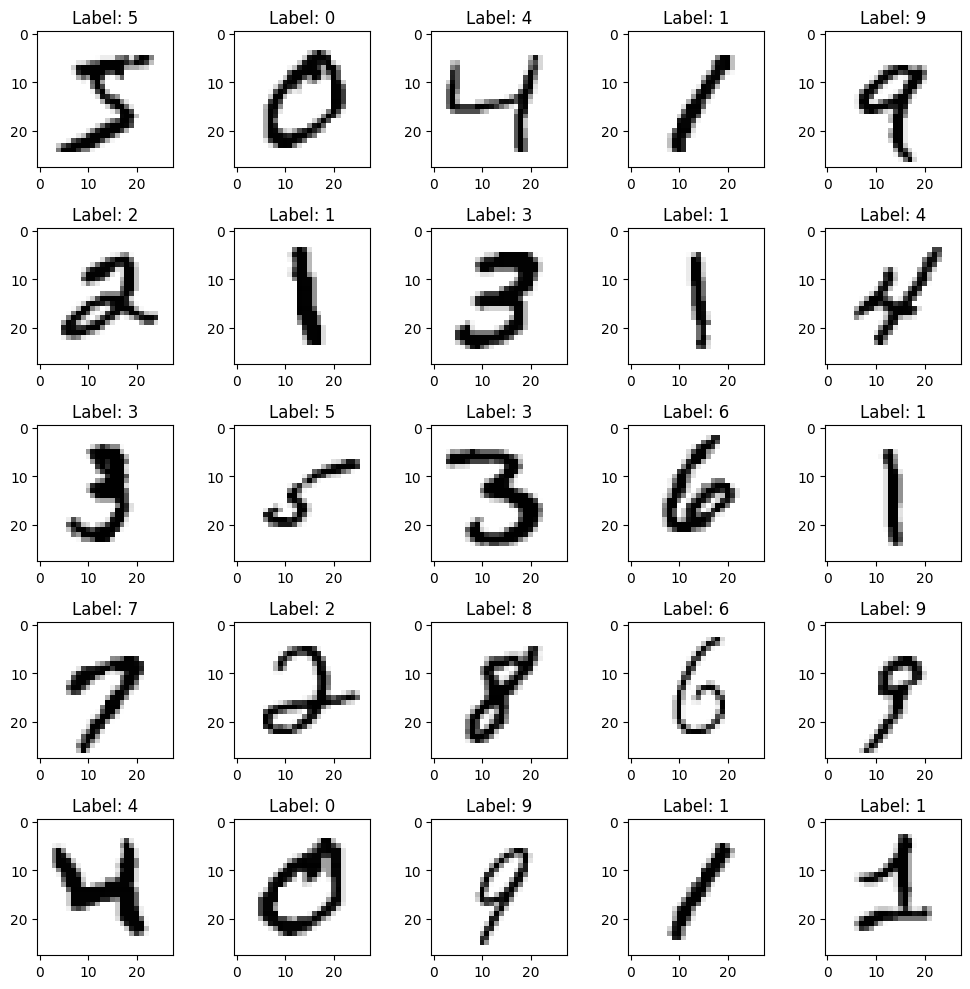

In [8]:
#  now showing  show some more images from  the data  sets

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()
for i in range(25):
    axes[i].imshow(x_train_full[i], cmap="binary")
    axes[i].set_title(f"Label: {y_train_full[i]}")

plt.tight_layout()
plt.show()


In [ ]:
# now  doing the scaling of the data  sets  and separating the validation data sets from the training data sets
# for scaling the data sets we will divide the data sets by 255 because the pixel values are between 0 and 255 and we want to scale them to be between 0 and 1
# for separating the validation data sets from the training data sets we will use the first 5000 images from the training data sets as the validation data sets and the rest as the training data sets
x_valid, x_train = x_train_full[:5000] / 255, x_train_full[5000:] / 255

y_valid, y_train = y_train_full[:5000], y_train_full[5000:]


In [ ]:
x_train_full.dtype


dtype('uint8')

In [ ]:
x_test


array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [12]:
x_test = x_test/255
x_test[0]


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [ ]:
x_valid[0]


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [ ]:
y_test


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [ ]:
#  here we assingn the class names to the labels in the data sets so that we can use them later for visualization and for understanding the data sets better
class_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]


In [ ]:
class_names


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [ ]:
# class_names[y_train[0] ]]   for example if we want to know the class name of the first image in the training data set we can use this code to get the class name of the first image in the training data set
class_names[y_train[0]]


'7'

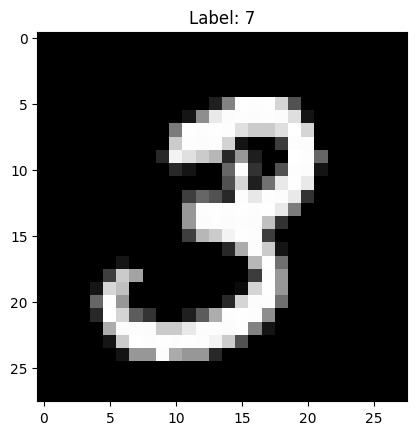

In [18]:
#  now  showing the first image in the training data set with its class name
plt.imshow(x_train[1], cmap="gray")
plt.title(f"Label: {class_names[y_train[0]]}")
plt.show()
# here we can see the first image in the training data set with its class name which is 5


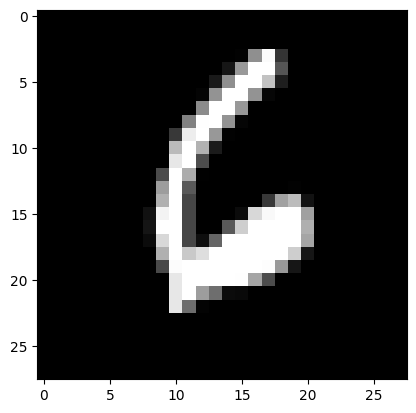

In [19]:
x_train[3]

plt.imshow(x_train[3], cmap="gray")
plt.show()


# Dense Layer 
```machine learning and deep learning, a dense layer (or fully connected layer) is a layer where every neuron is connected to every neuron in the preceding layer.```

How it WorksThe term "dense" refers to the high density of connections between the nodes. A dense layer functions as follows:
## Weighted Sum:
 It multiplies every input from the previous layer by a specific weight.Matrix Operations: It performs a dot product \(\text{output} = \text{activation}(\text{dot}(\text{input}, \text{kernel}) + \text{bias})\).
 
 ## Non-linearity: 
 
 It applies an activation function (like ReLU) to enable the network to learn complex patterns.
 Where it is UsedClassification / Prediction: Placed at the end of a network (like a Convolutional Neural Network) to turn extracted features into final classification scores.
 
 ```Multi-layer Perceptrons (MLP):```
  Used as the primary building block of standard feedforward neural networks.

Choosing the right number of neurons (like 300) is called hyperparameter tuning. There is no single mathematical formula to give you the perfect number, but data scientists find the right balance using specific rules of thumb and testing methods.

``` The Rule of Thumb (The Baseline)A common starting point is to set the number of neurons between the size of your input layer and your output layer.Example: If your input data has 784 features (like a \(28 \times 28\) image) and you are classifying it into 10 categories, 300 is a reasonable middle ground ((784 rightarrow 300  rightarrow 10\)).```




## The Power of Two Tradition ###
Programmers usually choose numbers that are powers of 2 (e.g., 32, 64, 128, 256, 512). This allows computer hardware (GPUs/CPUs) to process the data more efficiently in memory. Instead of exactly 300, you will often see 256 or 512.3. 
## How to Know If 300 is Too Many (Overfitting)##
Your number is too high if your model gets 99% accuracy on your training data but performs terribly on new, unseen validation data.Why: The network has too much capacity and just memorizes the training data instead of learning general patterns.

## The Fix: ##
Less neurons (e.g., drop from 300 to 128).4.
 How to Know If 300 is Too Few (Underfitting)Your number is too low if your model performs poorly on both your training data and your validation data.Why: The network is too "simple" or narrow to grasp the complexity of your data.The Fix: More neurons (e.g., increase from 300 to 512) or add an extra layer.5.


 ## The Best Method:

  AutomationIn practice, professionals do not guess. They use automated tools to try multiple values and pick the winner.Keras Tuner / Grid Search: You write a small script that automatically trains models with 64, 128, 256, and 512 neurons, compares their final validation accuracy, and tells you which number performed best.If you'd like, 
  
  let me know:What kind of data are you working with? 
  (e.g., images, text, tabular excel data)What is the total number of inputs (features) you are feeding into the model?

In [20]:

#  now Training the  model  with the training data sets and evaluating the model with the validation data sets and then testing the model with the test data sets

#   using the sequential API to build the model
# using keras


model = keras.models.Sequential()
#   here 28*28 =784
model.add(layers.Flatten(input_shape=[28, 28]))
model.add(layers.Dense(300, activation="relu"))
model.add(layers.Dense(100, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))
# Sigmoid: probabilities produced by a Sigmoid are independent.
# Softmax: the outputs are interrelated. The sum of all outputs are 1.


c:\Users\Hashir\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers


[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:

# https://keras.io/api/losses/
# https://keras.io/api/optimizers/#available-optimizers
# https://keras.io/api/metrics/

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])


In [24]:
x_train.shape


(55000, 28, 28)

In [ ]:
    # batch = The batch size is a hyperparameter that defines the number of samples to work through before updating the internal model parameters.
    # epochs = how many times to do a pass over all the dataset

    # https://keras.io/api/models/model_training_apis/#fit-method
history = model.fit(x_train, y_train, epochs=30, validation_data=(
    x_valid, y_valid), batch_size=32)  # also possible to use validation_split=0.1


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8497 - loss: 0.5937 - val_accuracy: 0.9158 - val_loss: 0.3029
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9186 - loss: 0.2835 - val_accuracy: 0.9352 - val_loss: 0.2394
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9328 - loss: 0.2315 - val_accuracy: 0.9426 - val_loss: 0.2024
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9436 - loss: 0.1985 - val_accuracy: 0.9524 - val_loss: 0.1740
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9502 - loss: 0.1738 - val_accuracy: 0.9586 - val_loss: 0.1558
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9557 - loss: 0.1545 - val_accuracy: 0.9606 - val_loss: 0.1441
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9603 - loss: 0.1387 - val_accuracy: 0.9624 - val_loss: 0.1350
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9645 - loss: 0

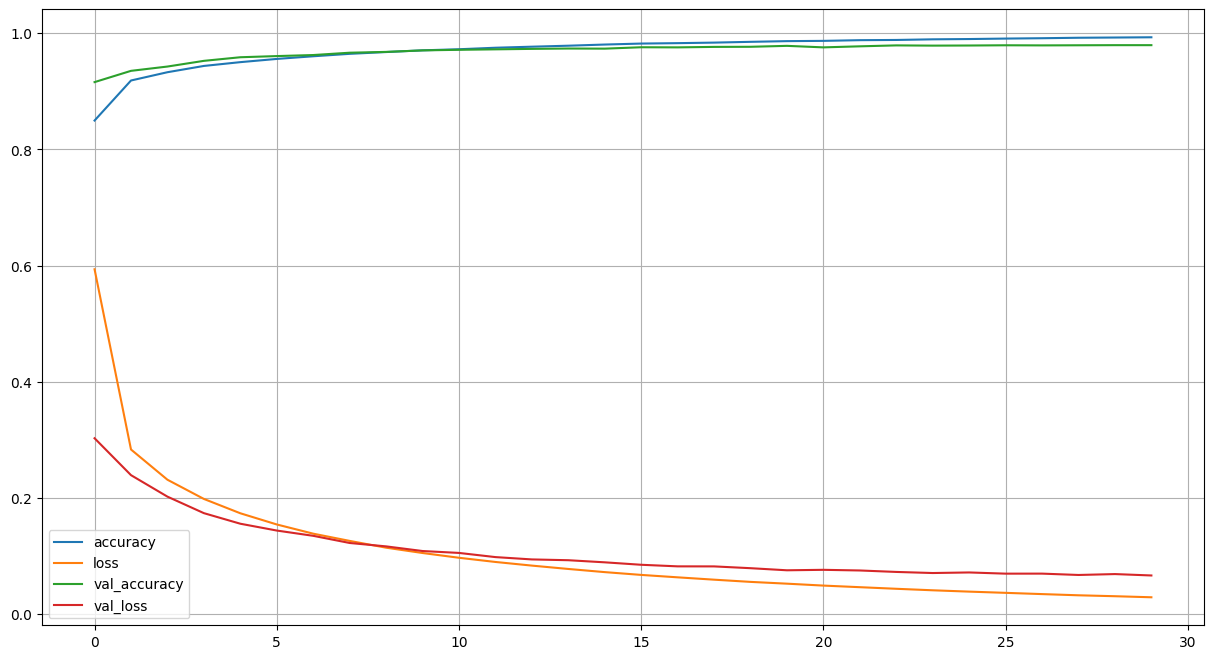

In [26]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
# plt.gca().set_ylim(0, 1)
plt.show()


In [27]:
history.history


{'accuracy': [0.8496727347373962,
  0.9185818433761597,
  0.9328363537788391,
  0.9436363577842712,
  0.9501636624336243,
  0.9557090997695923,
  0.9602727293968201,
  0.9644727110862732,
  0.9675454497337341,
  0.9704909324645996,
  0.9723636507987976,
  0.9749636650085449,
  0.9767636656761169,
  0.9784545302391052,
  0.9804545640945435,
  0.9821454286575317,
  0.9828545451164246,
  0.9837818145751953,
  0.9851272702217102,
  0.9863272905349731,
  0.9867818355560303,
  0.9879817962646484,
  0.9883454442024231,
  0.9894363880157471,
  0.9899272918701172,
  0.9907272458076477,
  0.9913454651832581,
  0.9921454787254333,
  0.9925454258918762,
  0.9929636120796204],
 'loss': [0.5937247276306152,
  0.28353604674339294,
  0.2315298616886139,
  0.19847290217876434,
  0.17379260063171387,
  0.15454170107841492,
  0.13870181143283844,
  0.12625879049301147,
  0.11458051949739456,
  0.10542096197605133,
  0.09722486138343811,
  0.09001173079013824,
  0.08374224603176117,
  0.07795930653810501,

In [28]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9795 - loss: 0.0701
Test Loss: 0.0701
Test Accuracy: 0.9795


In [29]:
# this will give us the probabilities of each class for the first 5 images in the test data set
model.predict(x_test[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


array([[4.8688530e-06, 1.4045509e-07, 2.2468284e-05, 1.3726219e-03,
        7.6259461e-08, 4.1438184e-06, 2.8019110e-11, 9.9849188e-01,
        2.1678093e-06, 1.0153886e-04],
       [1.8189991e-06, 3.4840978e-05, 9.9978536e-01, 1.5764721e-04,
        4.6210284e-12, 3.4012831e-07, 2.8608423e-07, 6.5578609e-10,
        1.9811436e-05, 1.3150156e-11],
       [1.5686394e-06, 9.9634761e-01, 2.0350216e-04, 7.6482058e-05,
        3.7727825e-04, 1.3270386e-05, 2.3632277e-04, 1.8788147e-03,
        8.4575644e-04, 1.9447587e-05],
       [9.9983287e-01, 7.7739465e-08, 8.9999332e-05, 1.8393061e-07,
        7.6811794e-08, 6.2157864e-07, 9.6199528e-06, 6.2508530e-05,
        4.8034365e-10, 3.9028805e-06],
       [3.6466728e-05, 6.8419560e-08, 7.9525907e-06, 8.9202430e-08,
        9.9816990e-01, 9.4949547e-07, 2.3611090e-05, 1.3934562e-04,
        3.7962727e-06, 1.6178340e-03]], dtype=float32)

In [30]:
y_prob = model.predict(x_test[:5])
y_prob.round(2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [31]:
y_classes = model.predict(x_test[:5]).argmax(axis=-1)
y_classes


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([7, 2, 1, 0, 4])

In [32]:
# for all the images in the test data set we will get the probabilities of each class for each image in the test data set
y_prob = model.predict(x_test)
y_prob.round(2)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10), dtype=float32)

In [33]:
# for all the images in the test data set we will get the class with the highest probability for each image in the test data set
y_classes = model.predict(x_test).argmax(axis=-1)

y_classes


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [34]:
confusion_matrix = tf.math.confusion_matrix(y_test, y_classes)
confusion_matrix


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 970,    1,    1,    0,    1,    2,    2,    1,    1,    1],
       [   0, 1123,    2,    1,    0,    1,    4,    1,    3,    0],
       [   4,    1, 1012,    2,    1,    0,    2,    4,    6,    0],
       [   1,    0,    6,  991,    0,    0,    0,    4,    4,    4],
       [   1,    0,    3,    1,  966,    0,    2,    2,    0,    7],
       [   3,    0,    1,    7,    1,  869,    4,    1,    3,    3],
       [   4,    2,    2,    0,    4,    2,  943,    0,    1,    0],
       [   1,    5,    8,    2,    0,    0,    0, 1001,    1,   10],
       [   6,    0,    4,    7,    2,    5,    5,    2,  940,    3],
       [   3,    2,    1,    6,    8,    4,    2,    2,    1,  980]],
      dtype=int32)>

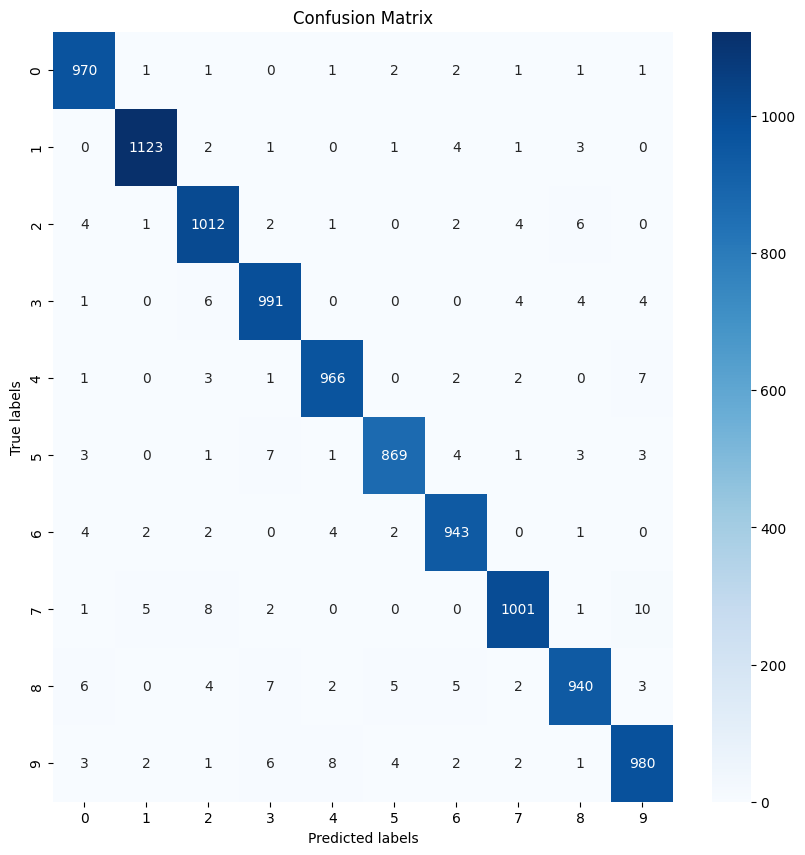

In [35]:
import seaborn as sns
plt.figure(figsize=(10, 8))
fig = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
fig.set(xlabel="Predicted Label", ylabel="True Label", title="Confusion Matrix ")
# labels, title and ticks
fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
fig.xaxis.set_ticklabels(class_names)
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)
